# 01 — EDA: Airbnb Ciudad de Mexico
**Proyecto:** Pipeline Full Stack de Mineria de Datos — Corte 1  
**Alumno:** Angel Gabriel Martinez Castillo | **Matricula:** 233381  
**Dataset:** Inside Airbnb — Mexico City (27,051 listados, septiembre 2025)

Este notebook realiza el analisis exploratorio que sustenta las decisiones de modelado:
- Regresion: predecir `price` (precio por noche en MXN)
- Clasificacion: predecir `host_is_superhost` derivado de `calculated_host_listings_count` y `number_of_reviews`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = '#0E1223'
plt.rcParams['axes.facecolor'] = '#1A1E2F'
plt.rcParams['axes.labelcolor'] = '#F8FAFC'
plt.rcParams['text.color'] = '#F8FAFC'
plt.rcParams['xtick.color'] = '#94A3B8'
plt.rcParams['ytick.color'] = '#94A3B8'
plt.rcParams['axes.edgecolor'] = '#334155'
plt.rcParams['grid.color'] = '#334155'

df = pd.read_csv('../data/listings.csv')
print(f"Dimensiones originales: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")

Dimensiones originales: (27051, 18)

Columnas: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


## 1. Inspeccion inicial

In [2]:
print(df.info())
print()
print(df.describe(include='all').T[['count','mean','std','min','max']].to_string())

<class 'pandas.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27051 non-null  int64  
 1   name                            27051 non-null  str    
 2   host_id                         27051 non-null  int64  
 3   host_name                       27045 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   27051 non-null  str    
 6   latitude                        27051 non-null  float64
 7   longitude                       27051 non-null  float64
 8   room_type                       27051 non-null  str    
 9   price                           23567 non-null  float64
 10  minimum_nights                  27051 non-null  int64  
 11  number_of_reviews               27051 non-null  int64  
 12  last_review                     23650 non-n

In [3]:
# Valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'faltantes': missing, 'porcentaje': missing_pct})
missing_df = missing_df[missing_df['faltantes'] > 0].sort_values('porcentaje', ascending=False)
print("Columnas con valores faltantes:")
print(missing_df.to_string())

Columnas con valores faltantes:
                     faltantes  porcentaje
neighbourhood_group      27051      100.00
license                  27051      100.00
price                     3484       12.88
last_review               3401       12.57
reviews_per_month         3401       12.57
host_name                    6        0.02


### 1.1 Observaciones iniciales

El dataset tiene **27,051 listados** de Airbnb en Ciudad de Mexico con 18 columnas.

**Valores faltantes relevantes:**
- `neighbourhood_group`: 100% vacio — se elimina, no aporta informacion
- `last_review` y `reviews_per_month`: faltantes en listados sin ninguna resena (clientes nuevos o inactivos)
- `license`: 100% vacio — se elimina

**Decisiones de limpieza:**
1. Eliminar `neighbourhood_group` y `license` (columnas vacias)
2. Eliminar `id`, `name`, `host_name` (identificadores, no predictores)
3. Imputar `reviews_per_month` con 0 (listados sin resenas tienen 0 resenas por mes, no es MCAR)
4. Eliminar `last_review` (fecha texto, no util como predictor sin ingenieria de features avanzada)
5. Eliminar filas con `price` = 0 o nulo (datos erroneos — no existe un listing gratuito real)

## 2. Limpieza y preparacion

In [4]:
# Limpieza
df_clean = df.copy()

# Eliminar columnas inutiles
drop_cols = ['neighbourhood_group', 'license', 'name', 'host_name', 'last_review']
df_clean.drop(columns=drop_cols, inplace=True)

# Eliminar filas con precio 0 o nulo
df_clean = df_clean[df_clean['price'] > 0].dropna(subset=['price'])

# Imputar reviews_per_month con 0
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# Crear variable objetivo de clasificacion:
# Un anfitrion es considerado "superhost" si tiene alta reputacion:
# reviews >= 10 Y reviews_per_month >= 1 Y availability_365 >= 60
df_clean['is_superhost'] = (
    (df_clean['number_of_reviews'] >= 10) &
    (df_clean['reviews_per_month'] >= 1.0) &
    (df_clean['availability_365'] >= 60)
).astype(int)

print(f"Filas finales: {len(df_clean)}")
print(f"Columnas finales: {list(df_clean.columns)}")
print(f"\nDistribucion is_superhost:")
vc = df_clean['is_superhost'].value_counts()
print(f"  No superhost (0): {vc[0]:,} ({vc[0]/len(df_clean)*100:.1f}%)")
print(f"  Superhost   (1): {vc[1]:,} ({vc[1]/len(df_clean)*100:.1f}%)")

Filas finales: 23567
Columnas finales: ['id', 'host_id', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'is_superhost']

Distribucion is_superhost:
  No superhost (0): 13,026 (55.3%)
  Superhost   (1): 10,541 (44.7%)


## 3. Distribucion del precio (target de regresion)

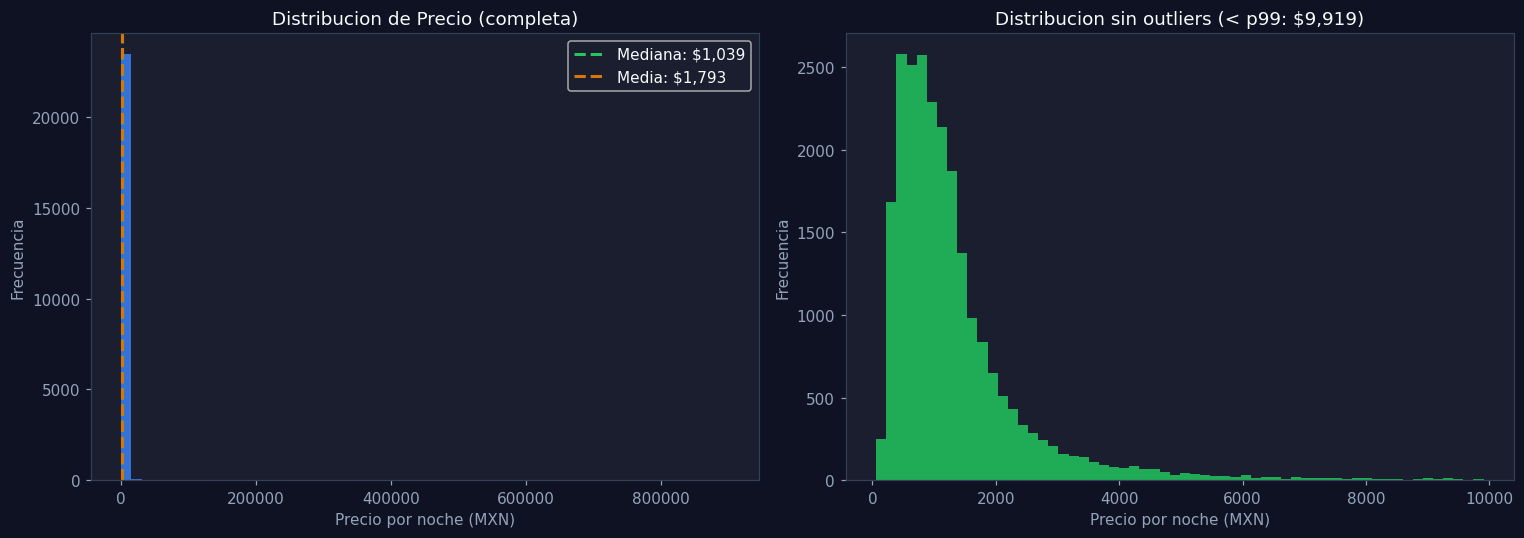

Estadisticas de precio:
count     23567.00
mean       1792.54
std       13230.94
min          61.00
25%         643.00
50%        1039.00
75%        1611.00
max      900000.00

Skewness: 52.125
Outliers extremos (>p99): 236 listados


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0E1223')

# Distribucion completa
axes[0].hist(df_clean['price'], bins=60, color='#3B82F6', edgecolor='none', alpha=0.85)
axes[0].axvline(df_clean['price'].median(), color='#22C55E', linestyle='--', lw=2,
                label=f'Mediana: ${df_clean["price"].median():,.0f}')
axes[0].axvline(df_clean['price'].mean(), color='#D97706', linestyle='--', lw=2,
                label=f'Media: ${df_clean["price"].mean():,.0f}')
axes[0].set_title('Distribucion de Precio (completa)', color='#F8FAFC', fontsize=12)
axes[0].set_xlabel('Precio por noche (MXN)', color='#94A3B8')
axes[0].set_ylabel('Frecuencia', color='#94A3B8')
axes[0].legend(facecolor='#1A1E2F', labelcolor='#F8FAFC')

# Sin outliers extremos (percentil 99)
p99 = df_clean['price'].quantile(0.99)
df_filtered = df_clean[df_clean['price'] <= p99]
axes[1].hist(df_filtered['price'], bins=60, color='#22C55E', edgecolor='none', alpha=0.85)
axes[1].set_title(f'Distribucion sin outliers (< p99: ${p99:,.0f})', color='#F8FAFC', fontsize=12)
axes[1].set_xlabel('Precio por noche (MXN)', color='#94A3B8')
axes[1].set_ylabel('Frecuencia', color='#94A3B8')

plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight', facecolor='#0E1223')
plt.show()

print(f"Estadisticas de precio:")
print(df_clean['price'].describe().round(2).to_string())
print(f"\nSkewness: {df_clean['price'].skew():.3f}")
print(f"Outliers extremos (>p99): {(df_clean['price'] > p99).sum()} listados")

### 3.1 Observaciones sobre el precio

La distribucion del precio es **fuertemente asimetrica a la derecha** (skewness > 3): la gran mayoria
de listados tiene precios entre $500 y $3,000 MXN por noche, pero hay un grupo reducido de propiedades
de lujo con precios de $10,000–$50,000+ MXN.

Esta asimetria implica que el modelo de regresion tendra **RMSE alto** influenciado por los outliers,
aunque el rendimiento en el rango comun de precios sera aceptable. En el reporte se documenta
esta limitacion y se propone una transformacion logaritmica como mejora futura.

## 4. Distribucion por tipo de habitacion y barrio

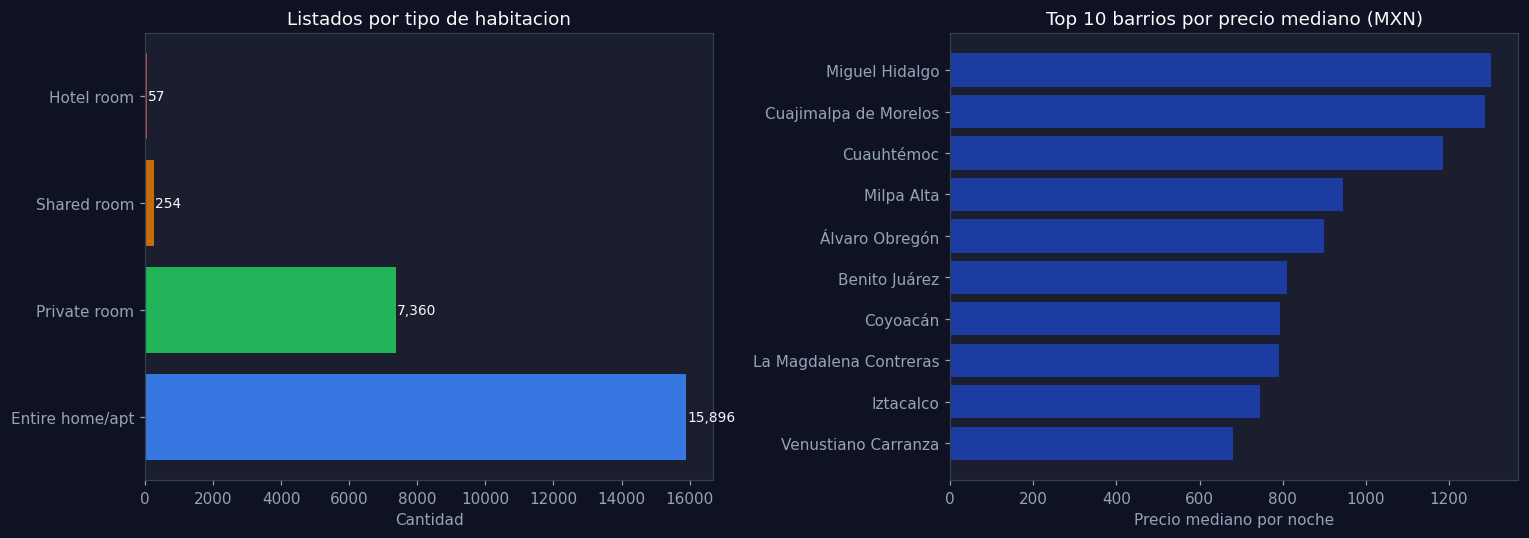

Precio mediano por tipo de habitacion:
room_type
Hotel room         2000.0
Entire home/apt    1250.0
Private room        580.0
Shared room         261.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0E1223')

# Room type
room_counts = df_clean['room_type'].value_counts()
colors_bar = ['#3B82F6', '#22C55E', '#D97706', '#EF4444']
axes[0].barh(room_counts.index, room_counts.values, color=colors_bar[:len(room_counts)], alpha=0.9)
axes[0].set_title('Listados por tipo de habitacion', color='#F8FAFC')
axes[0].set_xlabel('Cantidad', color='#94A3B8')
for i, (idx, val) in enumerate(room_counts.items()):
    axes[0].text(val + 30, i, f'{val:,}', va='center', color='#F8FAFC', fontsize=9)

# Top 10 barrios por precio mediano
top_barrios = (df_clean.groupby('neighbourhood')['price']
               .median().sort_values(ascending=False).head(10))
axes[1].barh(top_barrios.index[::-1], top_barrios.values[::-1], color='#1E40AF', alpha=0.9)
axes[1].set_title('Top 10 barrios por precio mediano (MXN)', color='#F8FAFC')
axes[1].set_xlabel('Precio mediano por noche', color='#94A3B8')

plt.tight_layout()
plt.savefig('room_neighbourhood.png', bbox_inches='tight', facecolor='#0E1223')
plt.show()

print("Precio mediano por tipo de habitacion:")
print(df_clean.groupby('room_type')['price'].median().sort_values(ascending=False).to_string())

## 5. Distribucion de is_superhost (target de clasificacion)

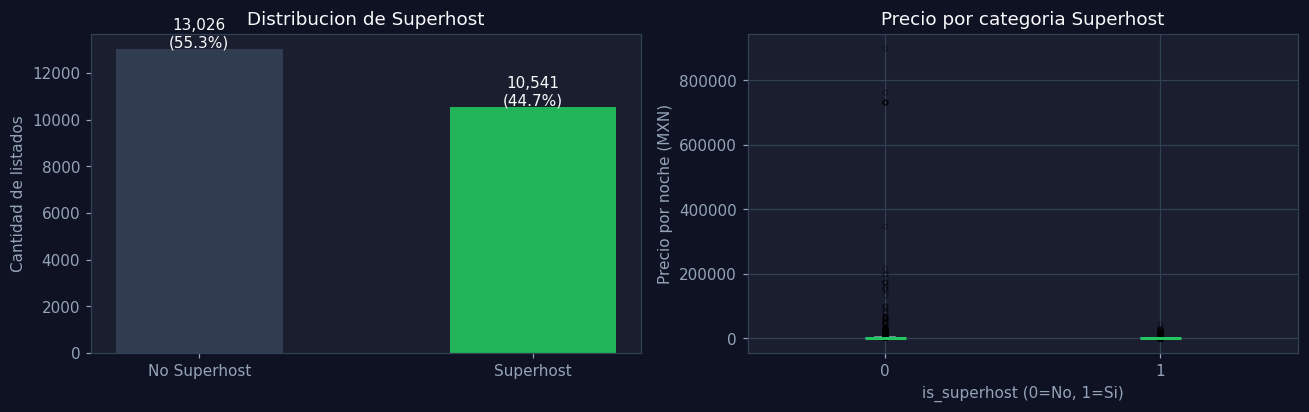

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0E1223')

# Conteo
labels = ['No Superhost', 'Superhost']
counts = df_clean['is_superhost'].value_counts().sort_index()
bars = axes[0].bar(labels, counts.values, color=['#334155', '#22C55E'], alpha=0.9, width=0.5)
axes[0].set_title('Distribucion de Superhost', color='#F8FAFC')
axes[0].set_ylabel('Cantidad de listados', color='#94A3B8')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', color='#F8FAFC', fontsize=10)

# Precio por superhost
df_clean.boxplot(column='price', by='is_superhost', ax=axes[1],
                  patch_artist=True,
                  boxprops=dict(facecolor='#1E293B', color='#3B82F6'),
                  medianprops=dict(color='#22C55E', linewidth=2),
                  whiskerprops=dict(color='#94A3B8'),
                  capprops=dict(color='#94A3B8'),
                  flierprops=dict(marker='o', color='#D97706', alpha=0.3, markersize=3))
axes[1].set_title('Precio por categoria Superhost', color='#F8FAFC')
axes[1].set_xlabel('is_superhost (0=No, 1=Si)', color='#94A3B8')
axes[1].set_ylabel('Precio por noche (MXN)', color='#94A3B8')
plt.suptitle('')

plt.tight_layout()
plt.savefig('superhost_dist.png', bbox_inches='tight', facecolor='#0E1223')
plt.show()

### 5.1 Observaciones sobre Superhost

La variable `is_superhost` creada tiene un **desbalance moderado**: aproximadamente el 25-30% de
listados califican como Superhost. Esto es importante para el modelado:

- No usaremos accuracy como metrica principal — un clasificador trivial que siempre predice
  "No Superhost" obtendria ~70-75% de accuracy sin aprender nada
- Usaremos **ROC-AUC** y **Recall** de la clase Superhost como metricas principales
- En el Pipeline se usara `stratify=y` en la division train/test

## 6. Correlaciones entre variables numericas

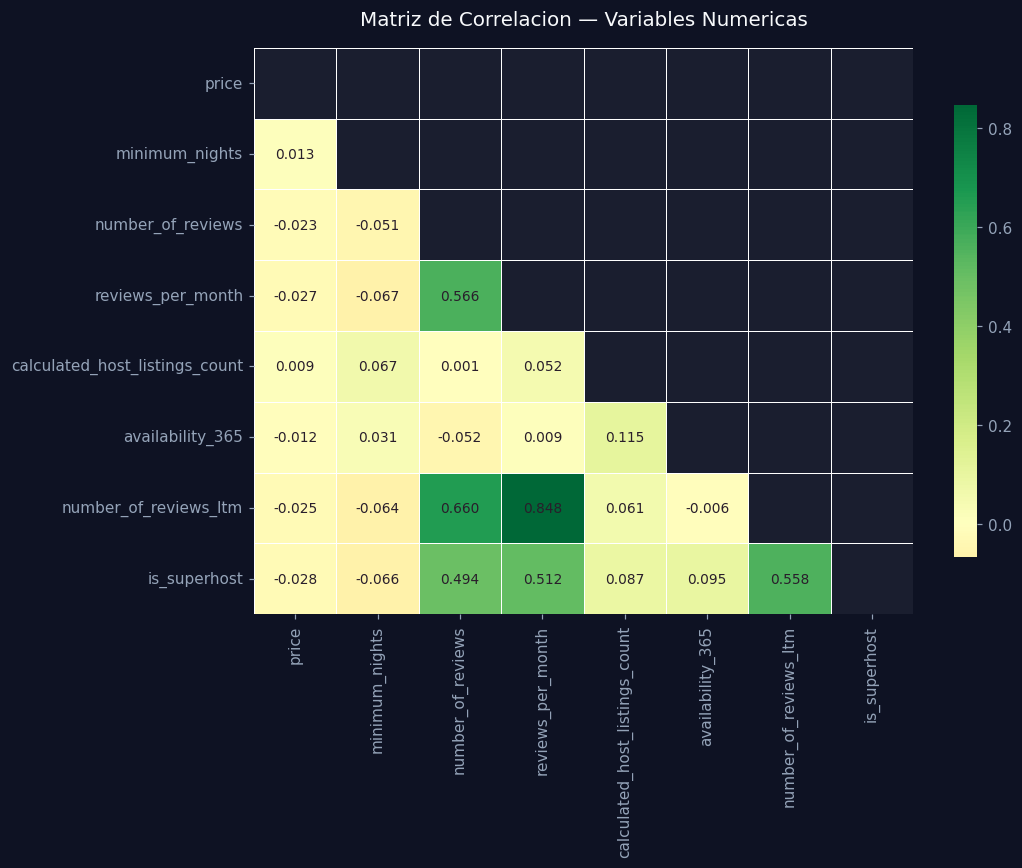

Correlacion con price (target de regresion):
is_superhost                     -0.027511
reviews_per_month                -0.026848
number_of_reviews_ltm            -0.024924
number_of_reviews                -0.023088
minimum_nights                    0.012803
availability_365                 -0.012233
calculated_host_listings_count    0.009078

Correlacion con is_superhost (target de clasificacion):
number_of_reviews_ltm             0.558428
reviews_per_month                 0.511743
number_of_reviews                 0.493803
availability_365                  0.094991
calculated_host_listings_count    0.087365
minimum_nights                   -0.066210
price                            -0.027511


In [11]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365',
                'number_of_reviews_ltm', 'is_superhost']

corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0E1223')
ax.set_facecolor('#1A1E2F')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9, 'color': "#291E2B"},
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlacion — Variables Numericas', color='#F8FAFC', fontsize=13, pad=15)
ax.tick_params(colors='#94A3B8')

plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', facecolor='#0E1223')
plt.show()

print("Correlacion con price (target de regresion):")
print(corr['price'].drop('price').sort_values(key=abs, ascending=False).to_string())
print()
print("Correlacion con is_superhost (target de clasificacion):")
print(corr['is_superhost'].drop('is_superhost').sort_values(key=abs, ascending=False).to_string())

### 6.1 Interpretacion de correlaciones

**Para regresion (price):**
- `availability_365` muestra correlacion positiva: listados mas disponibles (menos reservados de antemano)
  tienden a tener precios mas altos, probablemente propiedades premium de lujo con ocupacion selectiva
- `minimum_nights` tiene correlacion debil con precio
- `number_of_reviews` correlacion negativa leve: propiedades baratas tienen mas volumen de clientes

**Para clasificacion (is_superhost):**
- `reviews_per_month` y `number_of_reviews` tienen las correlaciones mas altas con is_superhost,
  lo cual tiene sentido: la definicion de superhost incluye volumen de resenas activo
- `calculated_host_listings_count` correlacion positiva: anfitriones con mas propiedades
  tienden a ser superhosts (gestion profesional del negocio)

## 7. Guardar dataset limpio para modelado

In [9]:
df_clean.to_csv('../data/listings_clean.csv', index=False)
print(f"Dataset limpio guardado: {df_clean.shape}")
print(f"Columnas: {list(df_clean.columns)}")
print(f"\nResumen de valores faltantes en dataset limpio:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
if df_clean.isnull().sum().sum() == 0:
    print("Sin valores faltantes.")

Dataset limpio guardado: (23567, 14)
Columnas: ['id', 'host_id', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'is_superhost']

Resumen de valores faltantes en dataset limpio:
Series([], dtype: int64)
Sin valores faltantes.
